In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
alldata = pd.read_csv("proteinbase_all_data.csv")
print(type(alldata.loc[0, "evaluations"]))
print(alldata.loc[0, "evaluations"])

print(alldata['evaluations'].loc[alldata.index[1]])
alldata

<class 'str'>
[{"type":"computational","value":"Not Assigned","metric":"design_class","valueType":"label"},{"type":"computational","unit":"Da","value":25259.321600000014,"metric":"molecular_weight","valueType":"numeric"},{"type":"computational","unit":"pH","value":5.340500831604003,"metric":"isoelectric_point","valueType":"numeric"},{"type":"computational","unit":"%","value":57.84548048048049,"metric":"esmfold_plddt","valueType":"numeric"},{"type":"computational","value":"Eeeeee","metric":"foldstring","valueType":"label"},{"type":"computational","value":"Mainly Beta","metric":"classification","valueType":"label"},{"type":"computational","value":2,"metric":"ted_confidence","valueType":"numeric"},{"type":"computational","unit":"%","value":98.7,"metric":"seqidentity","valueType":"numeric"},{"type":"computational","value":6.505e-9,"metric":"evalue","valueType":"numeric"},{"type":"computational","unit":"%","value":0.72457,"metric":"tm_score","valueType":"numeric"},{"type":"computational","u

,id,name,sequence,author,designMethod,evaluations
0,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,"[{""type"":""computational"",""value"":""Not Assigned..."
1,jade-otter-jade,1.3.3.18_2431_12,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,crg-ferruz-lab,protrl,"[{""type"":""experimental"",""value"":true,""metric"":..."
2,violet-ram-dust,1.3.3.18_4149_15,SPETDTINGLAKCPEEYIHFCIHGVCKFIQEQETPSCRCNKGYNGSRCE,crg-ferruz-lab,protrl,"[{""type"":""experimental"",""value"":true,""metric"":..."
3,dark-orca-crystal,1.3.3.18_1221_0,SNTVERCPSAHDTYCLYGGVCFYIPELQQYACNCVPGYVGERCQYS...,crg-ferruz-lab,protrl,"[{""type"":""experimental"",""value"":false,""metric""..."
4,soft-raven-frost,1.3.3.18_1409_17,SGPLRSPEPATDFPGRGLPCPVDHYCLNGGRCKFLEELQEYACECV...,crg-ferruz-lab,protrl,"[{""type"":""experimental"",""value"":true,""metric"":..."
...,...,...,...,...,...,...
1045,violet-moth-crystal,GPLSKAEYLEEQIKFVEENKDKKELVKPKLIETLKYVGYDEEAEYY...,GPLSKAEYLEEQIKFVEENKDKKELVKPKLIETLKYVGYDEEAEYY...,escalante-bio,mosaic,"[{""type"":""experimental"",""value"":true,""metric"":..."
1046,steady-bat-crystal,EVNCELLNKLAEPVAKELFPENDLAKISTFYAALFFAYEGALKGKP...,EVNCELLNKLAEPVAKELFPENDLAKISTFYAALFFAYEGALKGKP...,escalante-bio,mosaic,"[{""type"":""experimental"",""value"":true,""metric"":..."
1047,small-quail-opal,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,escalante-bio,mosaic,"[{""type"":""experimental"",""value"":true,""metric"":..."
1048,green-raven-ember,PD-L1,WQAYNKGMYVDKFRAEIVRFHHDQNPYMYIIWQWLVHVPPKVVKRR...,NaN,NaN,"[{""type"":""computational"",""value"":""Not Assigned..."


In [4]:
import json

alldata["evaluations"] = alldata["evaluations"].apply(json.loads)

# print(type(alldata.loc[0, "evaluations"]))

all_metrics = alldata.explode("evaluations", ignore_index=True)
all_metrics = all_metrics.join(pd.json_normalize(all_metrics.pop("evaluations")))
all_metrics

,id,name,sequence,author,designMethod,type,value,metric,valueType,unit,value.url,target
0,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,computational,Not Assigned,design_class,label,NaN,NaN,NaN
1,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,computational,25259.3216,molecular_weight,numeric,Da,NaN,NaN
2,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,computational,5.340501,isoelectric_point,numeric,pH,NaN,NaN
3,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,computational,57.84548,esmfold_plddt,numeric,%,NaN,NaN
4,gentle-cobra-lotus,PD-L1,ESGYAQNGDLEDAELDDYSFSCYSQLEVNGSQHSLTCAFEDPDVNI...,NaN,NaN,computational,Eeeeee,foldstring,label,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
45946,small-crow-marble,EGFR,LMFTHKRCCNFSWENDVYKDCFMITSVYMRPKSKETHAEGMVDAVW...,NaN,NaN,computational,2.7348,proteinmpnn_score,numeric,NaN,NaN,NaN
45947,small-crow-marble,EGFR,LMFTHKRCCNFSWENDVYKDCFMITSVYMRPKSKETHAEGMVDAVW...,NaN,NaN,computational,1.42608,redesigned_proteinmpnn_score,numeric,NaN,NaN,NaN
45948,small-crow-marble,EGFR,LMFTHKRCCNFSWENDVYKDCFMITSVYMRPKSKETHAEGMVDAVW...,NaN,NaN,computational,0.16866,proteinmpnn_seq_recovery,numeric,%,NaN,NaN
45949,small-crow-marble,EGFR,LMFTHKRCCNFSWENDVYKDCFMITSVYMRPKSKETHAEGMVDAVW...,NaN,NaN,computational,NaN,esmfold_structure_prediction,json,NaN,https://proteinbase-pub.t3.storage.dev/01K6MZG...,NaN


In [5]:
all_metrics["metric"].unique()

array(['design_class', 'molecular_weight', 'isoelectric_point',
       'esmfold_plddt', 'foldstring', 'classification', 'ted_confidence',
       'seqidentity', 'evalue', 'tm_score', 'rmsd', 'aligned_length',
       'cath_detail', 'proteinmpnn_score', 'redesigned_proteinmpnn_score',
       'proteinmpnn_seq_recovery', 'esmfold_structure_prediction',
       'esmfold_stylized_image', 'expressed', 'binding',
       'binding_strength', 'kd', 'kon', 'koff', 'bli_kinetic_curves',
       'seqidentityafdb50', 'evalueafdb50', 'tm-scoreafdb50',
       'rmsdafdb50', 'aligned-lengthafdb50', 'seqidentitycath50',
       'evaluecath50', 'tm-scorecath50', 'rmsdcath50',
       'aligned-lengthcath50', 'seqidentitypdb100', 'evaluepdb100',
       'tm-scorepdb100', 'rmsdpdb100', 'aligned-lengthpdb100', nan,
       'boltz2_plddt', 'boltz2_ptm', 'boltz2_iptm',
       'boltz2_complex_plddt', 'boltz2_complex_iplddt',
       'boltz2_complex_pde', 'boltz2_pdockq', 'boltz2_pdockq2',
       'boltz2_lis', 'interface_

The important metrics for now are: 'esmfold_plddt' 'rmsd' 'proteinmpnn_score' 'expressed' 'binding' 'binding_strength' 'kd' 'rmsdafdb50' 'rmsdcath50' 'rmsdpdb100' 'boltz2_plddt'

In [6]:
all_metrics["metric"].value_counts()

metric
expressed                       2527
bli_kinetic_curves              2526
binding                         2438
binding_strength                2437
esmfold_plddt                   2336
foldstring                      1283
classification                  1283
ted_confidence                  1283
cath_detail                     1236
seqidentitycath50               1231
rmsdcath50                      1231
tm-scorecath50                  1231
evaluecath50                    1231
aligned-lengthcath50            1231
rmsdafdb50                      1222
tm-scoreafdb50                  1222
aligned-lengthafdb50            1222
evalueafdb50                    1222
seqidentityafdb50               1222
rmsdpdb100                      1213
tm-scorepdb100                  1213
evaluepdb100                    1213
seqidentitypdb100               1213
aligned-lengthpdb100            1213
design_class                    1053
molecular_weight                1053
proteinmpnn_seq_recovery       

In [7]:
gentle_cobra = all_metrics[all_metrics["name"] == "PD-L1"]
gentle_cobra
# jade_otter_jade = out[out["id"] == "jade-otter-jade"]
# jade_otter_jade

small_quail = all_metrics[all_metrics["id"] == "small-quail-opal"]

# small_quail.head(37)

In [8]:
## Filter out all the rows without a designMethod.

alldata_filtered = all_metrics.dropna(subset=["designMethod"])

alldata_filtered

,id,name,sequence,author,designMethod,type,value,metric,valueType,unit,value.url,target
49,jade-otter-jade,1.3.3.18_2431_12,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,crg-ferruz-lab,protrl,experimental,True,expressed,boolean,NaN,NaN,NaN
50,jade-otter-jade,1.3.3.18_2431_12,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,crg-ferruz-lab,protrl,experimental,True,binding,boolean,NaN,NaN,egfr
51,jade-otter-jade,1.3.3.18_2431_12,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,crg-ferruz-lab,protrl,experimental,Medium,binding_strength,label,NaN,NaN,egfr
52,jade-otter-jade,1.3.3.18_2431_12,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,crg-ferruz-lab,protrl,experimental,0.0,kd,numeric,M,NaN,egfr
53,jade-otter-jade,1.3.3.18_2431_12,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,crg-ferruz-lab,protrl,experimental,37550.788416,kon,numeric,M,NaN,egfr
...,...,...,...,...,...,...,...,...,...,...,...,...
45888,small-quail-opal,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,escalante-bio,mosaic,computational,1.2829,proteinmpnn_score,numeric,NaN,NaN,NaN
45889,small-quail-opal,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,escalante-bio,mosaic,computational,0.86607,redesigned_proteinmpnn_score,numeric,NaN,NaN,NaN
45890,small-quail-opal,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,escalante-bio,mosaic,computational,0.63625,proteinmpnn_seq_recovery,numeric,%,NaN,NaN
45891,small-quail-opal,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,escalante-bio,mosaic,computational,NaN,esmfold_structure_prediction,json,NaN,https://proteinbase-pub.t3.storage.dev/01K6J32...,NaN


**I want to work with the ones where there is a design method, and now filter for the relevant metrics**

In [9]:
relevant_metrics = ['esmfold_plddt', 'rmsd', 'proteinmpnn_score', 'expressed', 'binding', 'binding_strength', 'kd', 'rmsdafdb50', 'rmsdcath50', 'rmsdpdb100', 'boltz2_plddt']
data_metrics = alldata_filtered[alldata_filtered["metric"].isin(relevant_metrics)]

data_metrics

,id,name,sequence,author,designMethod,type,value,metric,valueType,unit,value.url,target
49,jade-otter-jade,1.3.3.18_2431_12,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,crg-ferruz-lab,protrl,experimental,True,expressed,boolean,NaN,NaN,NaN
50,jade-otter-jade,1.3.3.18_2431_12,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,crg-ferruz-lab,protrl,experimental,True,binding,boolean,NaN,NaN,egfr
51,jade-otter-jade,1.3.3.18_2431_12,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,crg-ferruz-lab,protrl,experimental,Medium,binding_strength,label,NaN,NaN,egfr
52,jade-otter-jade,1.3.3.18_2431_12,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,crg-ferruz-lab,protrl,experimental,0.0,kd,numeric,M,NaN,egfr
56,jade-otter-jade,1.3.3.18_2431_12,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,crg-ferruz-lab,protrl,experimental,True,expressed,boolean,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
45874,small-quail-opal,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,escalante-bio,mosaic,computational,2.28,rmsdafdb50,numeric,Å,NaN,NaN
45880,small-quail-opal,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,escalante-bio,mosaic,computational,2.42,rmsdcath50,numeric,Å,NaN,NaN
45885,small-quail-opal,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,escalante-bio,mosaic,computational,2.87,rmsdpdb100,numeric,Å,NaN,NaN
45887,small-quail-opal,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,ALSEAEKKTIVGTAEAFARYALRYRKTKDPEDKWAVDTLLWMFESS...,escalante-bio,mosaic,computational,85.574233,esmfold_plddt,numeric,%,NaN,NaN


In [10]:
columns_to_drop = ['sequence', 'author', 'value.url', 'name']
data_clean = data_metrics.drop(columns=columns_to_drop, axis=1)
data_clean


,id,designMethod,type,value,metric,valueType,unit,target
49,jade-otter-jade,protrl,experimental,True,expressed,boolean,NaN,NaN
50,jade-otter-jade,protrl,experimental,True,binding,boolean,NaN,egfr
51,jade-otter-jade,protrl,experimental,Medium,binding_strength,label,NaN,egfr
52,jade-otter-jade,protrl,experimental,0.0,kd,numeric,M,egfr
56,jade-otter-jade,protrl,experimental,True,expressed,boolean,NaN,NaN
...,...,...,...,...,...,...,...,...
45874,small-quail-opal,mosaic,computational,2.28,rmsdafdb50,numeric,Å,NaN
45880,small-quail-opal,mosaic,computational,2.42,rmsdcath50,numeric,Å,NaN
45885,small-quail-opal,mosaic,computational,2.87,rmsdpdb100,numeric,Å,NaN
45887,small-quail-opal,mosaic,computational,85.574233,esmfold_plddt,numeric,%,NaN


I now want to clean it up a bit so that each metric is represented by one row only

In [11]:
metric_cols = ["value", "valueType", "unit"]

data_agg = data_clean.groupby(["id", "metric"]).agg({"value": lambda x: list(x), "valueType": lambda x: list(x), "unit": lambda x: list(x), "target": lambda x: list(set(x)), "designMethod": lambda x: list(set(x)), "type": lambda x: list(set(x))}).reset_index()

data_agg 

,id,metric,value,valueType,unit,target,designMethod,type
0,amber-bear-ice,binding,"[False, False]","[boolean, boolean]","[nan, nan]",[egfr],[bindcraft],[experimental]
1,amber-bear-ice,binding_strength,"[None, None]","[label, label]","[nan, nan]",[egfr],[bindcraft],[experimental]
2,amber-bear-ice,esmfold_plddt,"[86.40138783269967, 86.3354844778928]","[numeric, numeric]","[%, %]",[nan],[bindcraft],[computational]
3,amber-bear-ice,expressed,"[True, True]","[boolean, boolean]","[nan, nan]",[nan],[bindcraft],[experimental]
4,amber-bear-ice,proteinmpnn_score,[0.9897],[numeric],[nan],[nan],[bindcraft],[computational]
...,...,...,...,...,...,...,...,...
4004,young-quail-leaf,kd,"[4.17735180969538e-07, 3.9629446034907e-07, 3....","[numeric, numeric, numeric]","[M, M, M]",[egfr],[bindcraft],[experimental]
4005,young-quail-leaf,proteinmpnn_score,[1.9743],[numeric],[nan],[nan],[bindcraft],[computational]
4006,young-quail-leaf,rmsdafdb50,[1.57],[numeric],[Å],[nan],[bindcraft],[computational]
4007,young-quail-leaf,rmsdcath50,[1.72],[numeric],[Å],[nan],[bindcraft],[computational]


I'll now fill out each of the target cells which says nan so that it matches the given target shown in other cells (which were made into nan due to the exploding of evaluation data early on)

In [12]:
# Function to extract a non-nan value from a list
def extract_valid_target(lst):
    if not isinstance(lst, list):
        return np.nan
    values = [x for x in lst if pd.notna(x)]
    return values[0] if values else np.nan

# Creating a new helper column with a single representative target value per row
data_agg["target_clean"] = data_agg["target"].apply(extract_valid_target)

# Fill

data_agg["target_clean"] = (data_agg.groupby("id")["target_clean"].transform(lambda x: x.ffill().bfill()))

# Replace the orignial column with the clean one
data_agg["target"] = data_agg["target_clean"].apply(lambda x: [x] if pd.notna(x) else [np.nan])
data_agg.drop(columns="target_clean", inplace=True)

data_agg


,id,metric,value,valueType,unit,target,designMethod,type
0,amber-bear-ice,binding,"[False, False]","[boolean, boolean]","[nan, nan]",[egfr],[bindcraft],[experimental]
1,amber-bear-ice,binding_strength,"[None, None]","[label, label]","[nan, nan]",[egfr],[bindcraft],[experimental]
2,amber-bear-ice,esmfold_plddt,"[86.40138783269967, 86.3354844778928]","[numeric, numeric]","[%, %]",[egfr],[bindcraft],[computational]
3,amber-bear-ice,expressed,"[True, True]","[boolean, boolean]","[nan, nan]",[egfr],[bindcraft],[experimental]
4,amber-bear-ice,proteinmpnn_score,[0.9897],[numeric],[nan],[egfr],[bindcraft],[computational]
...,...,...,...,...,...,...,...,...
4004,young-quail-leaf,kd,"[4.17735180969538e-07, 3.9629446034907e-07, 3....","[numeric, numeric, numeric]","[M, M, M]",[egfr],[bindcraft],[experimental]
4005,young-quail-leaf,proteinmpnn_score,[1.9743],[numeric],[nan],[egfr],[bindcraft],[computational]
4006,young-quail-leaf,rmsdafdb50,[1.57],[numeric],[Å],[egfr],[bindcraft],[computational]
4007,young-quail-leaf,rmsdcath50,[1.72],[numeric],[Å],[egfr],[bindcraft],[computational]


First I need to exclude the ones which has the expressed metric == False, but only the ones where all of the values in the list are false

In [13]:
# Keep only the expressed metric
expressed_data = data_agg[data_agg["metric"] == "expressed"].copy()

# Define a function to check if all values in the list are False
def all_false(values):
    if not isinstance(values, list) or len(values) == 0:
        return False
    clean_vals = [v for v in values if pd.notna(v)]
    return all(v is False for v in clean_vals)

# Apply the function to mark which ID's have all False in expressed
expressed_data["all_false"] = expressed_data["value"].apply(all_false)

# Get the ID's to remove
id_to_remove = expressed_data.loc[expressed_data["all_false"], "id"].unique()

# Filter original df

data_filtered_exp = data_agg[~data_agg["id"].isin(id_to_remove)].copy()

data_filtered_exp

,id,metric,value,valueType,unit,target,designMethod,type
0,amber-bear-ice,binding,"[False, False]","[boolean, boolean]","[nan, nan]",[egfr],[bindcraft],[experimental]
1,amber-bear-ice,binding_strength,"[None, None]","[label, label]","[nan, nan]",[egfr],[bindcraft],[experimental]
2,amber-bear-ice,esmfold_plddt,"[86.40138783269967, 86.3354844778928]","[numeric, numeric]","[%, %]",[egfr],[bindcraft],[computational]
3,amber-bear-ice,expressed,"[True, True]","[boolean, boolean]","[nan, nan]",[egfr],[bindcraft],[experimental]
4,amber-bear-ice,proteinmpnn_score,[0.9897],[numeric],[nan],[egfr],[bindcraft],[computational]
...,...,...,...,...,...,...,...,...
4004,young-quail-leaf,kd,"[4.17735180969538e-07, 3.9629446034907e-07, 3....","[numeric, numeric, numeric]","[M, M, M]",[egfr],[bindcraft],[experimental]
4005,young-quail-leaf,proteinmpnn_score,[1.9743],[numeric],[nan],[egfr],[bindcraft],[computational]
4006,young-quail-leaf,rmsdafdb50,[1.57],[numeric],[Å],[egfr],[bindcraft],[computational]
4007,young-quail-leaf,rmsdcath50,[1.72],[numeric],[Å],[egfr],[bindcraft],[computational]


I also need to exclude the ones who didn't bind in vitro, binding == False

In [14]:
# Keep only the binding metric
binding_data = data_filtered_exp[data_filtered_exp["metric"] == "binding"].copy()

# Function is already defined. Mark rows where all binding values are False

binding_data["all_false"] = binding_data["value"].apply(all_false)

# Find IDs to remove
binding_id_to_remove = binding_data.loc[binding_data["all_false"], "id"].unique()

# Filter full dataset

data_filtered_exp = data_filtered_exp[~data_filtered_exp["id"].isin(binding_id_to_remove)].copy()

data_filtered_exp


,id,metric,value,valueType,unit,target,designMethod,type
65,amber-goat-onyx,binding,"[True, True, True]","[boolean, boolean, boolean]","[nan, nan, nan]",[fgf-r1],[pro-1],[experimental]
66,amber-goat-onyx,binding_strength,"[Medium, Medium, Medium]","[label, label, label]","[nan, nan, nan]",[fgf-r1],[pro-1],[experimental]
67,amber-goat-onyx,esmfold_plddt,"[86.85739376770537, 80.57501216545015]","[numeric, numeric]","[%, %]",[fgf-r1],[pro-1],[computational]
68,amber-goat-onyx,expressed,"[True, True, True]","[boolean, boolean, boolean]","[nan, nan, nan]",[fgf-r1],[pro-1],[experimental]
69,amber-goat-onyx,kd,"[1.02210666105499e-07, 9.48924426397673e-08, 9...","[numeric, numeric, numeric]","[M, M, M]",[fgf-r1],[pro-1],[experimental]
...,...,...,...,...,...,...,...,...
4004,young-quail-leaf,kd,"[4.17735180969538e-07, 3.9629446034907e-07, 3....","[numeric, numeric, numeric]","[M, M, M]",[egfr],[bindcraft],[experimental]
4005,young-quail-leaf,proteinmpnn_score,[1.9743],[numeric],[nan],[egfr],[bindcraft],[computational]
4006,young-quail-leaf,rmsdafdb50,[1.57],[numeric],[Å],[egfr],[bindcraft],[computational]
4007,young-quail-leaf,rmsdcath50,[1.72],[numeric],[Å],[egfr],[bindcraft],[computational]


I will now figure out the mean values for each metric, in relation to the design methods.

In [ ]:
# Make a copy of above filtered DF to make sure I don't modify the original.

list_columns = ["valueType", "unit", "target", "designMethod", "type"]

data_copy = data_filtered_exp.copy()

for col in list_columns:
    if col in data_copy.columns:
        data_copy[col] = data_copy[col].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)

# Make a function that flattens my list values and takes the mean
def flatten_and_mean(values):
    """Take a list and returns its mean, ignoring NaN."""
    if isinstance(values, list): # Keep only numeric values
        nums = []
        for v in values:
            if isinstance(v, list):
                nums.extend([x for x in v if isinstance(x, (int, float))])
            elif isinstance(v, (int, float)):
                nums.append(v)
        return sum(nums) / len(nums) if nums else None
    
    elif isinstance(values, (int, float)):
        return values
    
    return None 

# Apply the function
data_copy["numeric_value"] = data_copy["value"].apply(flatten_and_mean)

# Filter to numeric metrics
data_numeric = data_copy[data_copy["numeric_value"].notna()].copy()

# group by design method and metric
design_metric_data = (data_numeric.groupby(["designMethod", "metric"], as_index=False).agg(mean_value=("numeric_value", "mean")))

# pivot so metric is a column

design_metric_data_pivot = design_metric_data.pivot(index="designMethod", columns="metric", values="mean_value").reset_index()

design_metric_data_pivot.columns.name = None

# Filter out metrics which have a very different value.

filtered_data = design_metric_data[design_metric_data["metric"] != "kd"]
filtered_data2 = filtered_data[filtered_data["metric"] != "esmfold_plddt"]

heatmap_data = filtered_data2.pivot(index="metric", columns="designMethod", values="mean_value")

data_copy


,id,metric,value,valueType,unit,target,designMethod,type,numeric_value
65,amber-goat-onyx,binding,"[True, True, True]",boolean,NaN,fgf-r1,pro-1,experimental,1.000000e+00
66,amber-goat-onyx,binding_strength,"[Medium, Medium, Medium]",label,NaN,fgf-r1,pro-1,experimental,NaN
67,amber-goat-onyx,esmfold_plddt,"[86.85739376770537, 80.57501216545015]",numeric,%,fgf-r1,pro-1,computational,8.371620e+01
68,amber-goat-onyx,expressed,"[True, True, True]",boolean,NaN,fgf-r1,pro-1,experimental,1.000000e+00
69,amber-goat-onyx,kd,"[1.02210666105499e-07, 9.48924426397673e-08, 9...",numeric,M,fgf-r1,pro-1,experimental,9.571417e-08
...,...,...,...,...,...,...,...,...,...
4004,young-quail-leaf,kd,"[4.17735180969538e-07, 3.9629446034907e-07, 3....",numeric,M,egfr,bindcraft,experimental,3.940767e-07
4005,young-quail-leaf,proteinmpnn_score,[1.9743],numeric,NaN,egfr,bindcraft,computational,1.974300e+00
4006,young-quail-leaf,rmsdafdb50,[1.57],numeric,Å,egfr,bindcraft,computational,1.570000e+00
4007,young-quail-leaf,rmsdcath50,[1.72],numeric,Å,egfr,bindcraft,computational,1.720000e+00


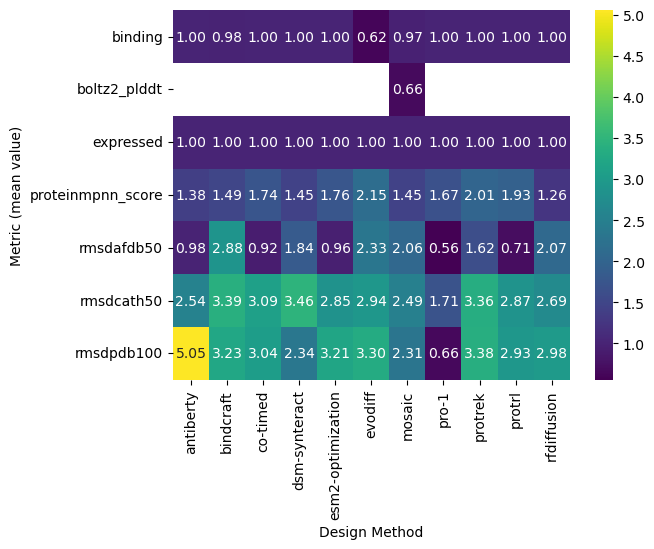

In [ ]:
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="viridis")
plt.ylabel("Metric (mean value)")
plt.xlabel("Design Method")
plt.show()

I want to make individual boxplots for each metric that shows the distribution of values for the design methods. I can use some of the same data sets from the cell before

In [ ]:
# First I need to flatten the value column with a function, kind of like above but without taking the mean

def flatten_values(values):
    if isinstance(values, list):
        nums = [x for x in values if isinstance(x, (int, float))]
        return nums if nums else None
    return [values] if isinstance(values, (int, float)) else None

# Create value list if it's not there

data_copy_2 = data_copy.copy()

data_copy_2["value_single"] = data_copy_2["value"].apply(flatten_values)

# explode to make one value per row (only if value_list actually contains list)
data_copy_2 = data_copy_2.explode("value_single", ignore_index=True)

# Sort for clarity

data_copy_2 = data_copy_2.sort_values(by=["metric", "designMethod"])

data_copy_2 = data_copy_2.drop(columns=["numeric_value"])

numeric_data = data_copy_2[data_copy_2["valueType"] == "numeric"]

numeric_data

,id,metric,value,valueType,unit,target,designMethod,type,value_single
1961,bright-swan-lotus,boltz2_plddt,[0.7227082252502441],numeric,%,il7r,mosaic,computational,0.722708
1962,brisk-goat-snow,boltz2_plddt,[0.579907238483429],numeric,%,il7r,mosaic,computational,0.579907
1963,crimson-mole-quartz,boltz2_plddt,[0.6838041543960571],numeric,%,pd-l1,mosaic,computational,0.683804
1964,crimson-tiger-flint,boltz2_plddt,[0.638350784778595],numeric,%,pd-l1,mosaic,computational,0.638351
1965,frozen-panda-maple,boltz2_plddt,[0.6739462614059448],numeric,%,il7r,mosaic,computational,0.673946
...,...,...,...,...,...,...,...,...,...
7637,steady-swan-onyx,rmsdpdb100,[2.83],numeric,Å,il7r,rfdiffusion,computational,2.83
7638,swift-panda-snow,rmsdpdb100,[4.08],numeric,Å,il7r,rfdiffusion,computational,4.08
7639,vast-ant-crystal,rmsdpdb100,[3.46],numeric,Å,il7r,rfdiffusion,computational,3.46
7640,wild-crane-rose,rmsdpdb100,[3.67],numeric,Å,il7r,rfdiffusion,computational,3.67


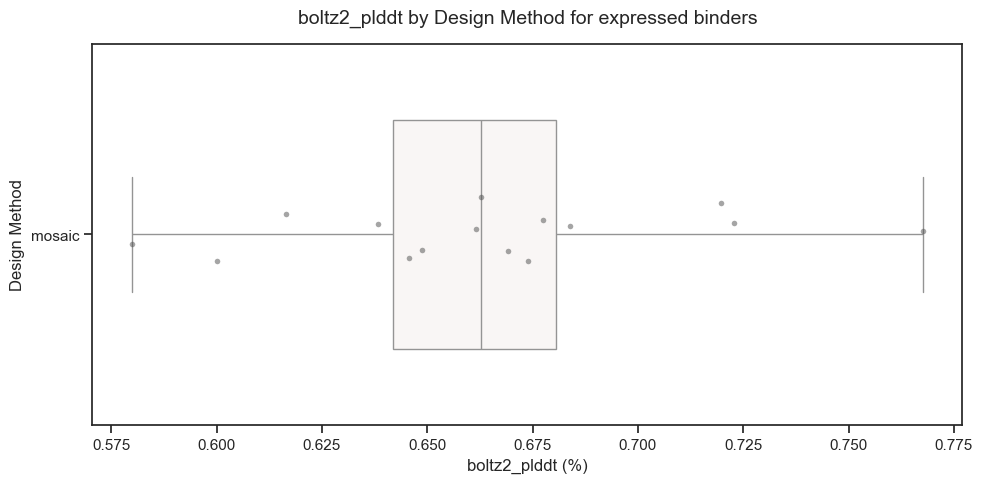

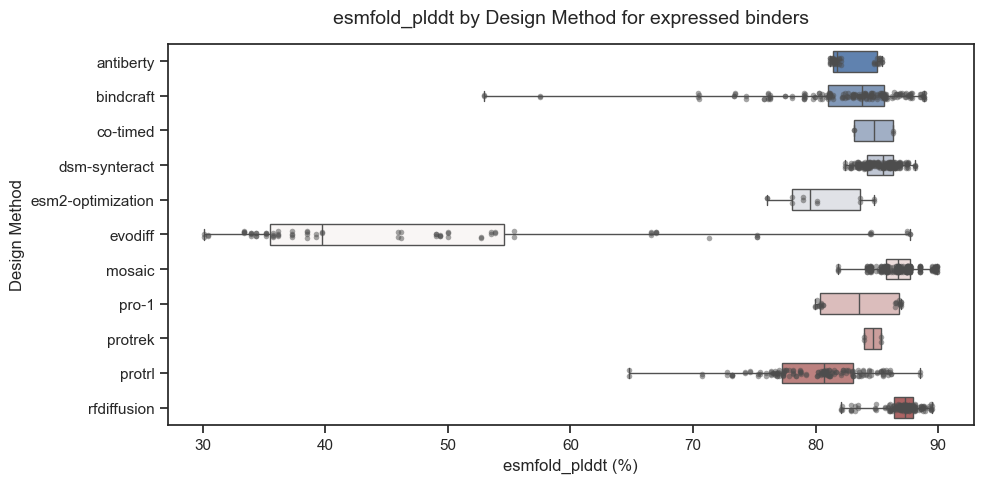

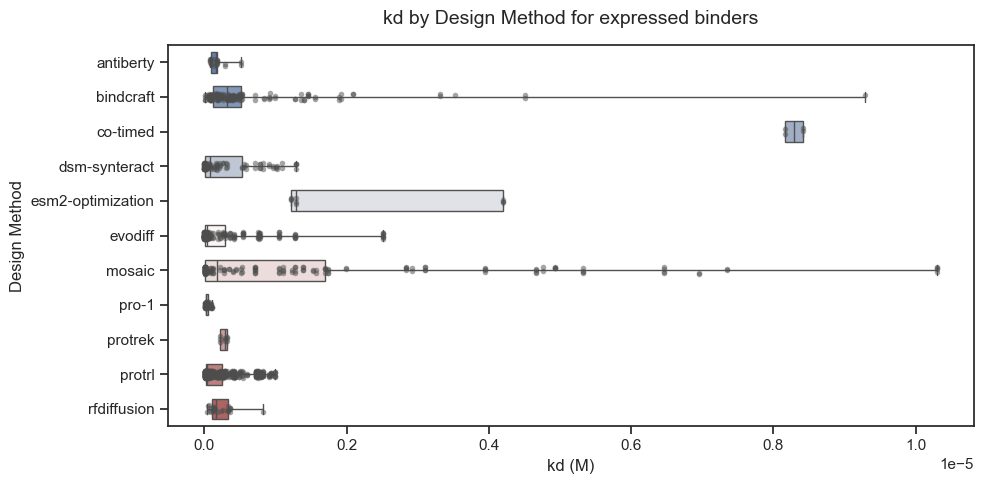

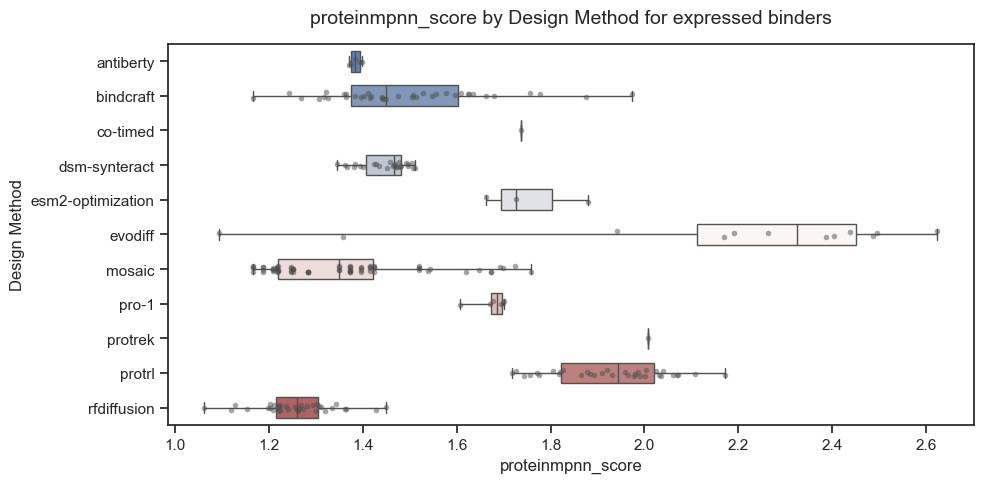

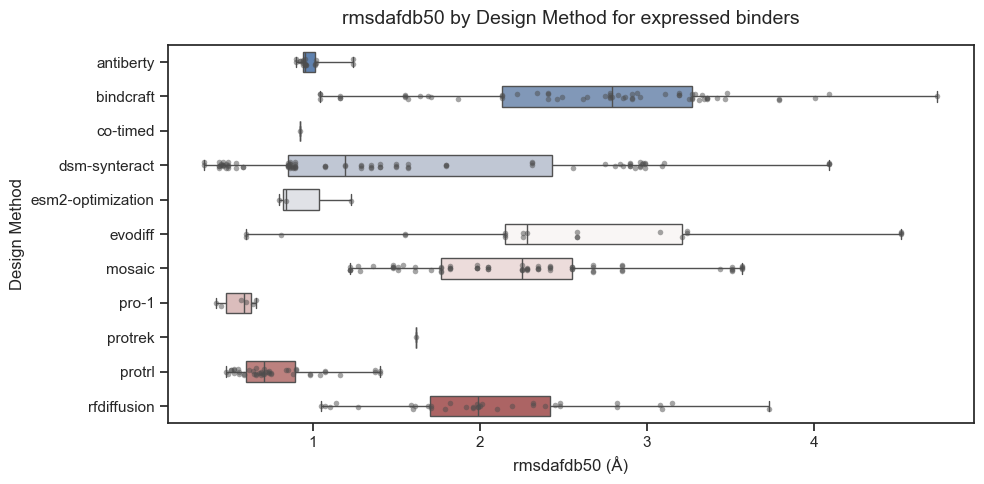

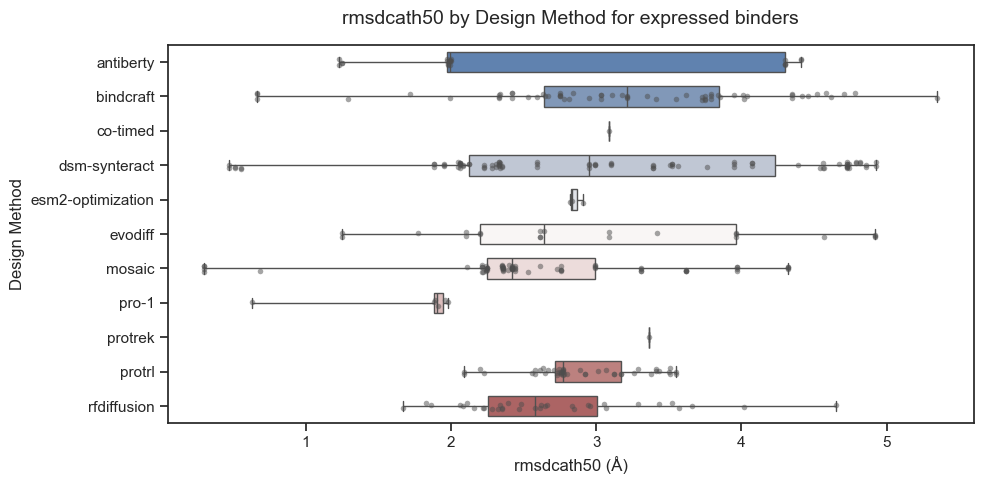

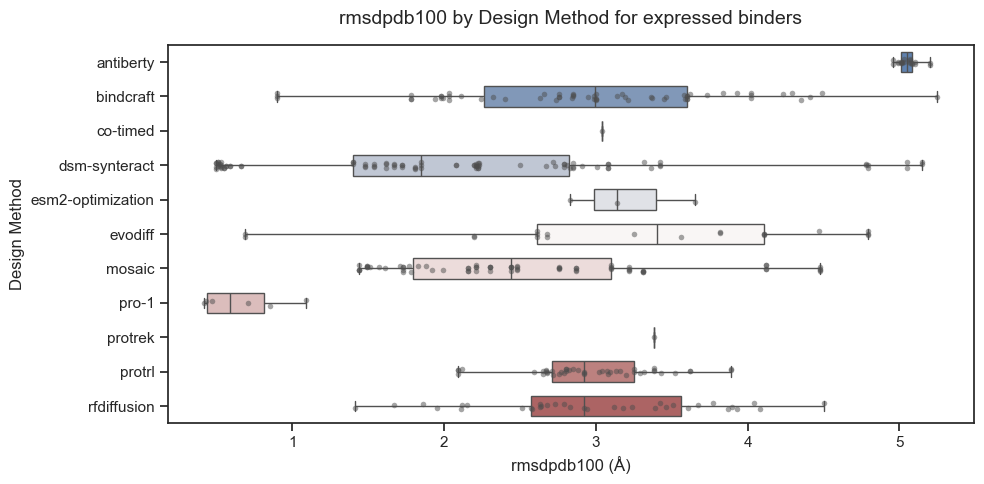

In [ ]:
# Making boxplots

# Get unique metrics

metrics = numeric_data["metric"].dropna().unique()
sns.set_theme(style="ticks", font_scale=1)

for m in metrics:
    subset = numeric_data[numeric_data["metric"] == m]

    unit = subset["unit"].dropna().unique()
    unit_label = f" ({unit[0]})" if len(unit) > 0 else ""

    plt.figure(figsize=(10, 5))
    ax = sns.boxplot(data=subset, y="designMethod", x="value_single", hue="designMethod", whis=[0, 100], orient="h", width=0.6, palette="vlag", fliersize=3, legend=False)

    sns.stripplot(data=subset, y="designMethod", x="value_single", orient="h", color=".3", size=4, alpha=0.5, jitter=True)

    ax.set_title(f"{m} by Design Method for expressed binders", fontsize=14, pad=15)
    ax.set_xlabel(f"{m}{unit_label}")
    ax.set_ylabel("Design Method")
    
    plt.tight_layout()
    plt.show()


In [18]:
# For future use when going through this or other data sets, a reusable filtering function. Note that this function expects the column name to be "metric" and the value column to be named "value".
# Also uses the previously defined all_false function, so compile these two together.

def remove_all_false(df, metric_name):
    temp = df[df["metric"] == metric_name].copy()
    temp["all_false"] = temp["value"].apply(all_false)
    bad_ids = temp.loc[temp["all_false"], "id"].unique()
    return df[~df["id"].isin(bad_ids)].copy()


Now the data needs to be grouped by design method, so that all, for example proteinmpnn_scores, are aggregated and compied independently of ID but by design method. Then the mean of all those values for the given designmethod should be taken

In [19]:
# Cell to inspect individual IDs

id_groups = {id_val: df_id for id_val, df_id in data_agg.groupby("id")}
id_groups["jade-otter-jade"]

,id,metric,value,valueType,unit,target,designMethod,type
1541,jade-otter-jade,binding,"[True, True, True]","[boolean, boolean, boolean]","[nan, nan, nan]",[egfr],[protrl],[experimental]
1542,jade-otter-jade,binding_strength,"[Medium, Medium, Medium]","[label, label, label]","[nan, nan, nan]",[egfr],[protrl],[experimental]
1543,jade-otter-jade,esmfold_plddt,"[77.0532535885168, 83.91292191435775, 77.38724...","[numeric, numeric, numeric]","[%, %, %]",[egfr],[protrl],[computational]
1544,jade-otter-jade,expressed,"[True, True, True]","[boolean, boolean, boolean]","[nan, nan, nan]",[egfr],[protrl],[experimental]
1545,jade-otter-jade,kd,"[4.0438673274385e-07, 3.8824950673733e-07, 3.5...","[numeric, numeric, numeric]","[M, M, M]",[egfr],[protrl],[experimental]
1546,jade-otter-jade,proteinmpnn_score,[2.1727],[numeric],[nan],[egfr],[protrl],[computational]
1547,jade-otter-jade,rmsdafdb50,"[1.37, 0.98]","[numeric, numeric]","[Å, Å]",[egfr],[protrl],[computational]
1548,jade-otter-jade,rmsdcath50,"[3.55, 3.51]","[numeric, numeric]","[Å, Å]",[egfr],[protrl],[computational]
1549,jade-otter-jade,rmsdpdb100,"[3.38, 3.62]","[numeric, numeric]","[Å, Å]",[egfr],[protrl],[computational]


**This sorts by whether or not the given ID is expressed or not. It does so by looking at if all of the different runs for each ID as expressed == True as there's multiple values for each ID. It also groups by design method and type of design but the metric expressed is only visible for the experimental and not the computational**

In [20]:
expressed_metric = alldata_filtered[alldata_filtered["metric"] == "expressed"]
expressed_id = expressed_metric.groupby("id").agg({"value": "any", "designMethod": lambda x: list(x.unique()), "type": lambda x: list(x.unique())}).reset_index()

expressed_id.rename(columns={"value": "expressed_all"}, inplace=True)
expressed_id

,id,expressed_all,designMethod,type
0,amber-bear-ice,True,[bindcraft],[experimental]
1,amber-bear-plume,True,[bindcraft],[experimental]
2,amber-boar-clay,True,[bindcraft],[experimental]
3,amber-boar-lava,True,[bindcraft],[experimental]
4,amber-boar-snow,True,[co-timed],[experimental]
...,...,...,...,...
484,young-hawk-ash,True,[co-timed],[experimental]
485,young-otter-lotus,True,[protrl],[experimental]
486,young-owl-dust,True,[protrl],[experimental]
487,young-panther-cypress,True,[bindcraft],[experimental]


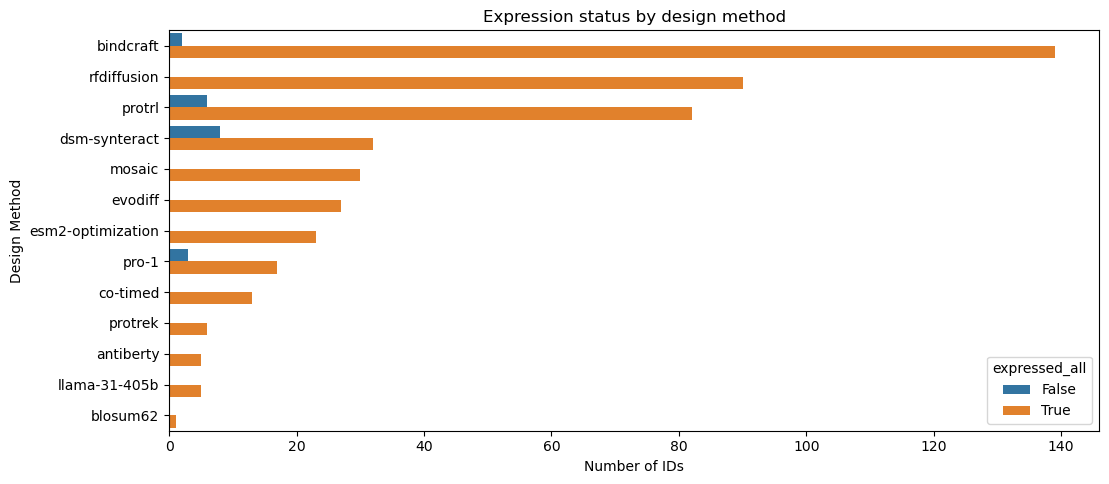

In [21]:
exploded_exp_id = expressed_id.explode("designMethod")

plt.figure(figsize=(12, len(exploded_exp_id["designMethod"].unique()) * 0.4))
sns.countplot(data=exploded_exp_id, y="designMethod", hue="expressed_all", order=exploded_exp_id["designMethod"].value_counts().index)
plt.xlabel("Number of IDs")
plt.ylabel("Design Method")
plt.title("Expression status by design method")
plt.show()

